In [4]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

In [5]:
# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)

# Download Fashion MNIST from Kaggle
print("Downloading Fashion MNIST dataset...")
path = kagglehub.dataset_download("zalando-research/fashionmnist")
print(f"Dataset downloaded to: {path}")

Dataset downloaded to: /Users/andreaigner/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4


In [6]:
train_data = pd.read_csv(os.path.join(path, 'fashion-mnist_train.csv'))
print(f"Training data shape: {train_data.shape}")
print(train_data.head())

Training data shape: (60000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel78

In [7]:
X_features = train_data.drop('label', axis=1)
y = train_data['label']
print(f"Label: {y}")

Label: 0        2
1        9
2        6
3        0
4        3
        ..
59995    9
59996    1
59997    8
59998    8
59999    7
Name: label, Length: 60000, dtype: int64


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(X_features)
X_scaler = X

In [9]:
pca = PCA(n_components=2)
X = pca.fit_transform(X)
print(X.shape)

(60000, 2)


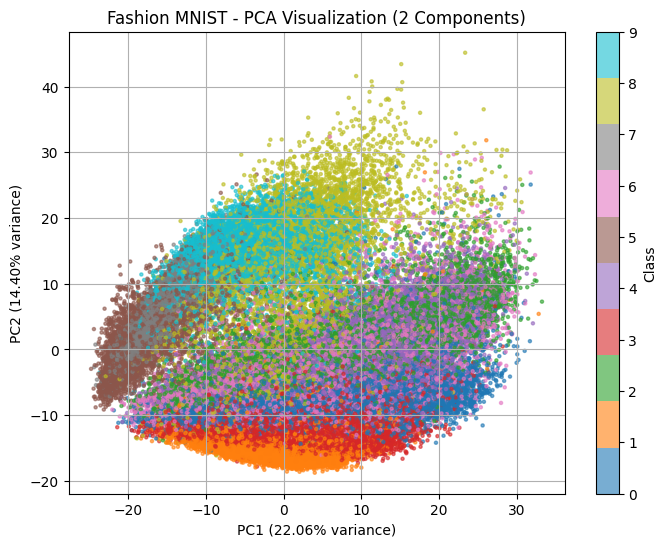

(60000, 2)


In [10]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], 
                     c=y, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Fashion MNIST - PCA Visualization (2 Components)')
plt.grid(True)
plt.show()
print(X.shape)

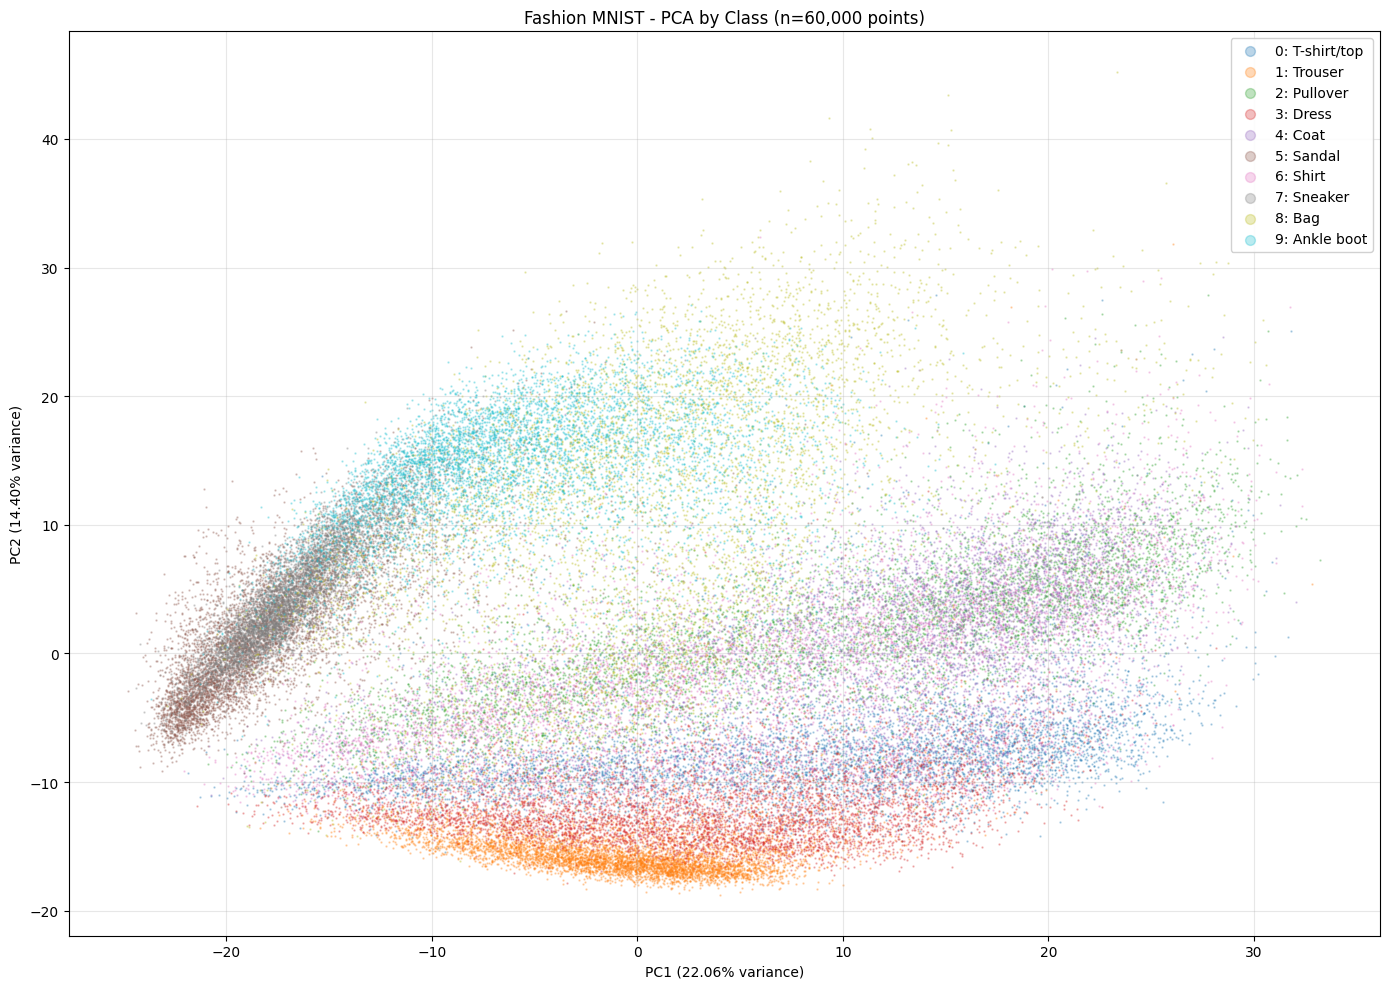


Total points plotted: 60000
Points per class:
  0: T-shirt/top: 6000
  1: Trouser: 6000
  2: Pullover: 6000
  3: Dress: 6000
  4: Coat: 6000
  5: Sandal: 6000
  6: Shirt: 6000
  7: Sneaker: 6000
  8: Bag: 6000
  9: Ankle boot: 6000


In [11]:
plt.figure(figsize=(14, 10))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot all points with smaller size and lower alpha
for i, class_name in enumerate(class_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], 
               label=f'{i}: {class_name}', alpha=0.3, s=0.5, rasterized=True)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Fashion MNIST - PCA by Class (n={len(X):,} points)')
plt.legend(markerscale=10, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print stats to verify all points are included
print(f"\nTotal points plotted: {len(X)}")
print(f"Points per class:")
for i, class_name in enumerate(class_names):
    count = (y == i).sum()
    print(f"  {i}: {class_name}: {count}")

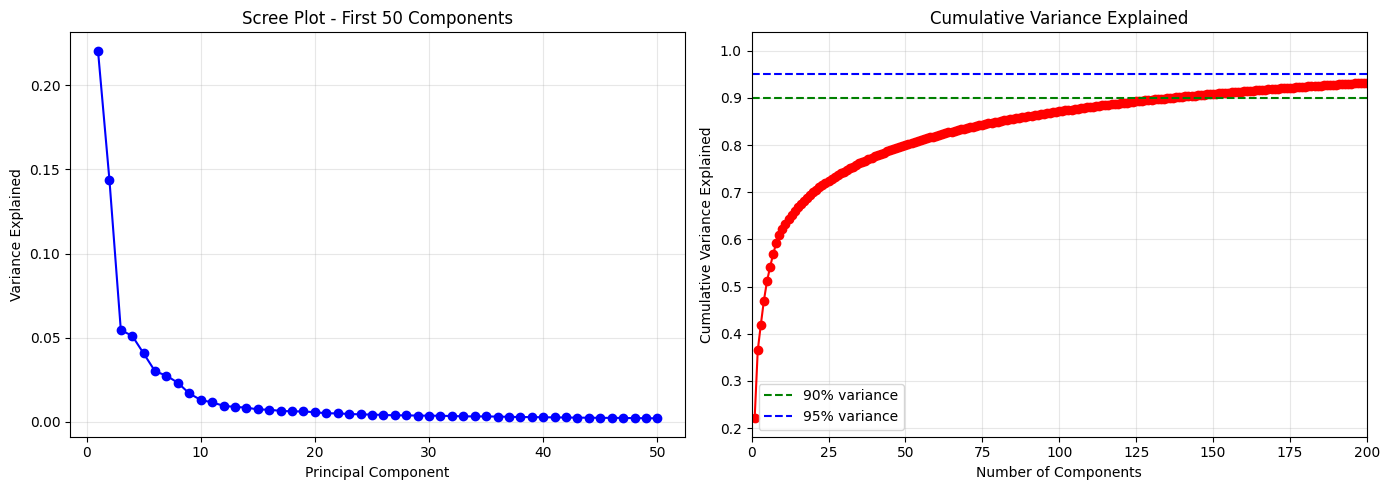

Components for 90% variance: 137
Components for 95% variance: 256


In [12]:
# 1. Analyze variance explained - how many components do we really need?
pca_full = PCA()
pca_full.fit(X_scaler)

plt.figure(figsize=(14, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, 51), pca_full.explained_variance_ratio_[:50], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot - First 50 Components')
plt.grid(True, alpha=0.3)

# Cumulative variance
plt.subplot(1, 2, 2)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, 'ro-')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# How many components needed?
n_90 = np.argmax(cumsum >= 0.90) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")